### Scott 10K sigdiff (violinplots only)

#### Making a violinplot with the correct legend because I realised I made a mistake and CN patients are labelled as MCI in my violinplots


#### Violinplots

desikan_coeffs C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/desikan_coeffs_sig_diff.csv
PRINTING VIOLIN PLOT - WIDTH = 50, HEIGHT = 12.5


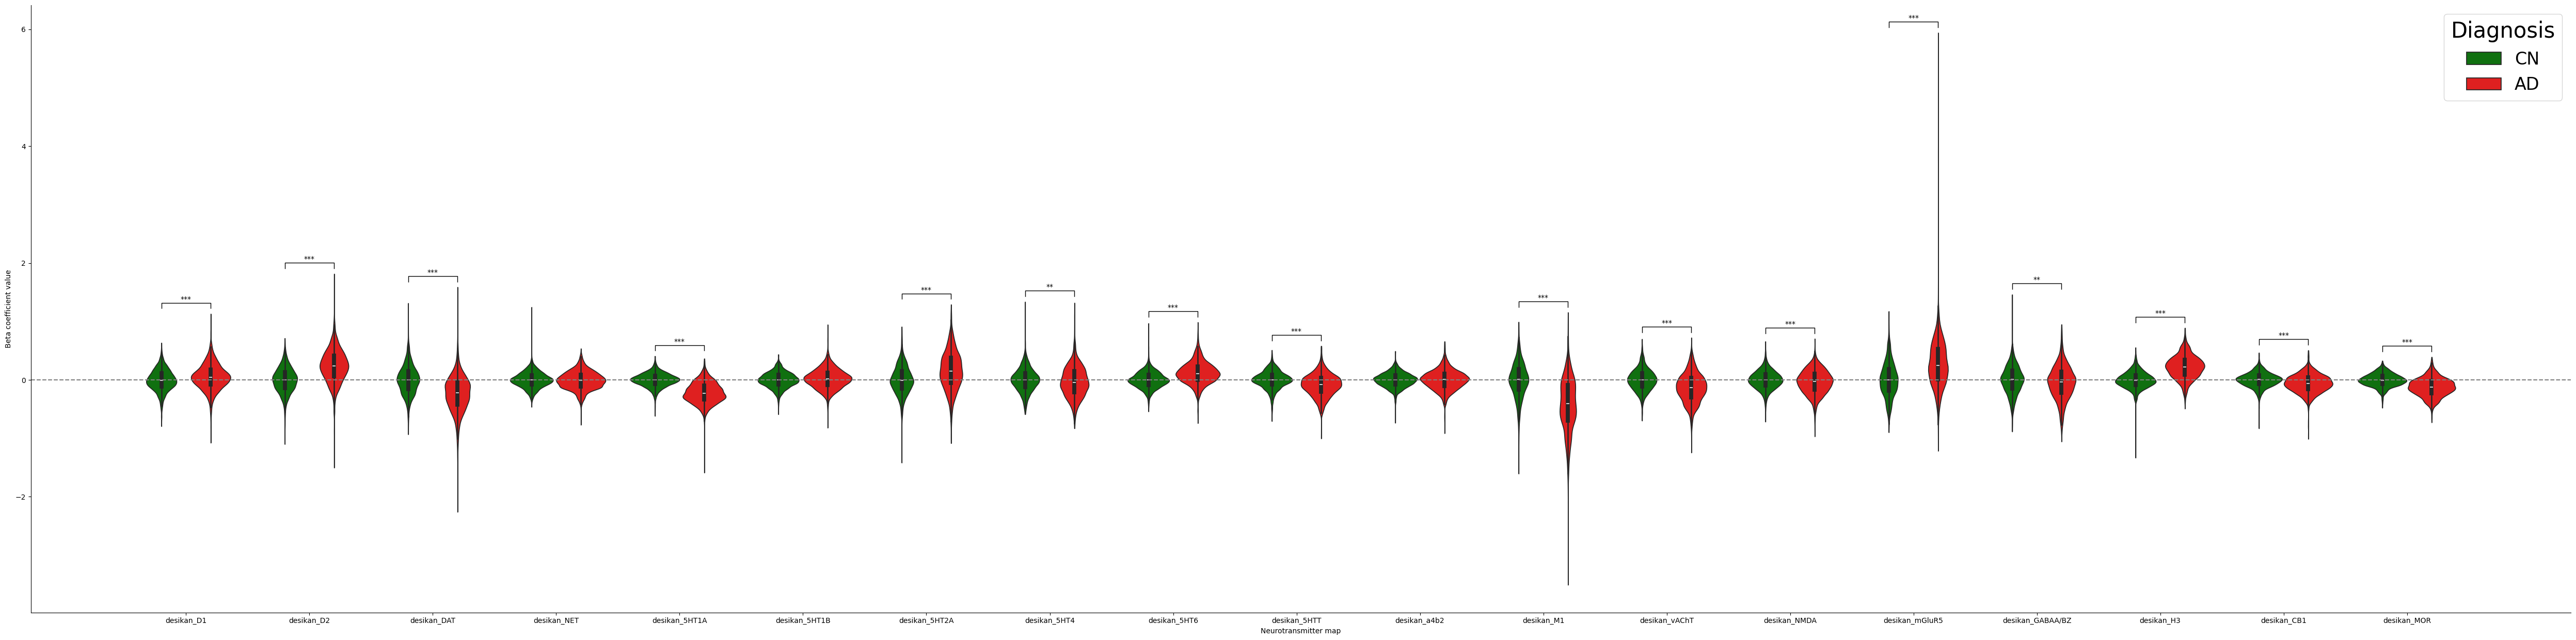

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, sys
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests
from matplotlib import font_manager

font_path = "C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/arial.ttf"
font_manager.fontManager.addfont(font_path)

# Updated path name for violin plots
violinplot_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/violinplots'
os.makedirs(violinplot_path, exist_ok = True)

def get_significance_stars(p_value):
    if p_value < 0.001: return '***'
    elif 0.001 <= p_value < 0.01: return '**'
    elif 0.01 <= p_value < 0.05: return '*'
    else: return 'ns'

coeff_path = 'C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/desikan_coeffs.csv'

df = pd.read_csv(coeff_path, low_memory=False)
diag_df = pd.read_csv('C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_housekeeping/no_neuroimaging_data_scott10k_alliedhealth.csv', 
                      low_memory=False)[['DATA_KEY', 'DIAGNOSIS']]

merged = pd.merge(diag_df, df, on='DATA_KEY', how='inner')
cn_ad_df = merged[merged['DIAGNOSIS'].isin([1, 3])].drop(columns = 'DATA_KEY')

melted_df = cn_ad_df.melt(id_vars='DIAGNOSIS', var_name='NEUROTRANSMITTER', value_name='VALUE')


v_min = melted_df['VALUE'].min()
v_max = melted_df['VALUE'].max()

stats_df = pd.read_csv(
    f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv",
    low_memory = False)

print(os.path.basename(coeff_path).replace('.csv', ''), f"C:/Users/User/Downloads/deconstructalz.github.io/scott_10k_analysis/sig_diff/{os.path.basename(coeff_path).replace('.csv', '')}_sig_diff.csv")

# Removed the dot_size loop as it doesn't apply to violin plots
width  = 50
height = max(6, float(width / 4))
print(f"PRINTING VIOLIN PLOT - WIDTH = {width}, HEIGHT = {height}")

pval_dict = dict(zip(stats_df['Coefficient'], stats_df['Corrected_P']))
    
plt.figure(figsize = (width, height))

# CHANGED TO VIOLINPLOT
ax = sns.violinplot(
    data = melted_df, 
    x = 'NEUROTRANSMITTER', 
    y = 'VALUE', 
    hue ='DIAGNOSIS', 
    palette = {1: 'green', 3: 'red'},
    split = False,      # Merges the two diagnosis halves into one violin
    cut = 0            # Limits the violin to the data range (prevents weird tails)
)
        
ax.set_yscale("linear")

plt.xlabel('Neurotransmitter map')
plt.ylabel('Beta coefficient value')

# Calculate padding for stars
y_range = v_max - v_min
padding = y_range * 0.05
ax.set_ylim(v_min - padding, v_max + padding)

x_order = melted_df['NEUROTRANSMITTER'].unique()
y_max_per_nt = melted_df.groupby('NEUROTRANSMITTER')['VALUE'].max()

# 6. Add Brackets and Stars

    
for i, nt in enumerate(x_order):
    if nt in pval_dict:
        stars = get_significance_stars(pval_dict[nt])
        
        if stars != 'ns':
            # Fix 2: Use y_max_per_nt variable defined in step 4
            y_base = y_max_per_nt[nt] + 0.02 * y_range  
            y_tips = y_base - 0.01 * y_range    
            
            x1, x2 = i - 0.2, i + 0.2
            
            ax.plot([x1, x1, x2, x2], [y_tips, y_base, y_base, y_tips], lw=1, color='black')
            ax.text((x1 + x2) / 2, y_base, stars, ha='center', va='bottom', fontsize=10)
plt.axhline(y = 0, color = 'grey', linestyle = 'dashed')
sns.despine()
handles, labels = ax.get_legend_handles_labels()
leg = plt.legend(handles[0:2], ['CN', 'AD'], loc='upper right', title='Diagnosis', fontsize = 24)
plt.setp(leg.get_title(),fontsize = 30)
plt.tight_layout()
# Updated naming convention
#final_path = os.path.join(violinplot_path, f"{os.path.basename(coeff_path).replace('_coeffs.csv','')}_CORR_LEGEND_full_violin_w{width}_h{height}.png")
#plt.savefig(final_path, dpi = 300)
plt.show()
plt.close()